# Satish, Juan, Greg Housing Project

First import the relevant libraries / ML functions and read the dataset:

In [133]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report


In [108]:
import pandas as pd
data = pd.read_csv("../data/king_ country_ houses_aa.csv")

Explore the dataset: shape, data types, features, target variable 

In [109]:
print("Data shape:",data.shape)
print("Data types:\n", data.dtypes)
data.head()
# "price" is our target variable
# the others are our features
# "date" is object - we may want to convert it into ordinals / integers.

Data shape: (21613, 21)
Data types:
 id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [110]:
print(data.zipcode.unique().shape) # Zipcode is categorical and non-ordinal!
print(data.condition.unique().shape) # Condition is ordinal 1 to 5
print(data.grade.unique().shape) # Grade is from 1 to 13 (there are no 2s) - ordinal
print(data.waterfront.unique().shape) # Waterfront is binary
print(data.view.unique().shape) # Views is ordinal 0 to 4 (number of views by potential buyers)
print(data.floors.unique().shape) # Floors is ordinal

(70,)
(5,)
(12,)
(2,)
(5,)
(6,)


In [111]:
print(data.zipcode.unique().shape) # 70 different zipcodes
print(data.view.value_counts()) 
print(data.grade.value_counts())

(70,)
view
0    19489
2      963
3      510
1      332
4      319
Name: count, dtype: int64
grade
7     8981
8     6068
9     2615
6     2038
10    1134
11     399
5      242
12      90
4       29
13      13
3        3
1        1
Name: count, dtype: int64


In [112]:
data.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [113]:
data.isnull().sum()
#data.columns
data.isna().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [114]:
print("="*20,"DESCRIBE","*"*20)
print(data.describe(include='all'))
print("="*20,"INFO","*"*20)
print(data.info())
print("="*20,"VALUE COUNTS","*"*20)
print(data.value_counts())
print("="*20,"UNIQUE VALUES","*"*20)
count_uniques = data.nunique()
print(count_uniques)
print("="*20,"HEAD","*"*20)
print(data.head())

==================== DESCRIBE ********************
                  id             date         price      bedrooms  \
count   2.161300e+04            21613  2.161300e+04  21613.000000   
unique           NaN              372           NaN           NaN   
top              NaN  20140623T000000           NaN           NaN   
freq             NaN              142           NaN           NaN   
mean    4.580302e+09              NaN  5.400881e+05      3.370842   
std     2.876566e+09              NaN  3.671272e+05      0.930062   
min     1.000102e+06              NaN  7.500000e+04      0.000000   
25%     2.123049e+09              NaN  3.219500e+05      3.000000   
50%     3.904930e+09              NaN  4.500000e+05      3.000000   
75%     7.308900e+09              NaN  6.450000e+05      4.000000   
max     9.900000e+09              NaN  7.700000e+06     33.000000   

           bathrooms   sqft_living      sqft_lot        floors    waterfront  \
count   21613.000000  21613.000000  2.16

In [115]:
print("Data duplicates:", data.duplicated().sum())
print("ID row data duplicates:", data["id"].duplicated().sum())


Data duplicates: 0
ID row data duplicates: 177


There are no duplicates in the data as a whole!
However, only looking at "id", there are 177 duplicates, meaning that 177 houses are mentioned more than once. But they differ in "date", meaning they were sold at different points in time.

Let us now convert the "date"-column into an ordinal variable (datetime64):

In [116]:
print(data.date.head())
data['date'] = pd.to_datetime(data['date'])
data["year"] = data["date"].dt.year
data["month"] = data["date"].dt.month
data["day"] = data["date"].dt.day
print(data.columns)

0    20141013T000000
1    20141209T000000
2    20150225T000000
3    20141209T000000
4    20150218T000000
Name: date, dtype: object
Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15', 'year', 'month', 'day'],
      dtype='object')


We decided to treat zipcode as categorical (together with date). The variables lat and long already carry spatial information, so we can use them for the machine learning algorithm.
Variables such as view, condition, grade can be included in the analysis as they are ordinal.

In [117]:
data_num = data.select_dtypes(include="number") # Numerical columns only
data_num = data_num.drop(columns=["zipcode"]) # We want to exclude zipcode as it is in fact categorical
print(data_num.columns)
data_cat = data.select_dtypes(exclude="number") # Only contains "date"
data_cat = pd.concat([data_cat, data["zipcode"]], axis=1) # We want to add zipcode here
print(data_cat.columns)

Index(['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'year', 'month', 'day'],
      dtype='object')
Index(['date', 'zipcode'], dtype='object')


We derive "house age" from "yr_built" to make it more easy to handle and interpret.
Also, we transform "yr_renovated" into "is_renovated" to avoid discrepancies between 0 and large numbers. 

In [118]:
data["house_age"] = 2015 - data.yr_built
data.house_age.head()

0    60
1    64
2    82
3    50
4    28
Name: house_age, dtype: int64

In [119]:
data['is_renovated'] = data['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)

The final data frame we use for the machine learning algorithms consists of the numerical columns, as well as our newly defined house age and "is_renovated". We drop columns "yr_built" and "yr_renovated" in return:

In [120]:
data_final = pd.concat([data_num, data[["house_age","is_renovated"]]], axis=1)
data_final = data_final.drop(columns=["yr_built", "yr_renovated"])
data_final.head()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_basement,lat,long,sqft_living15,sqft_lot15,year,month,day,house_age,is_renovated
0,7129300520,221900.0,3,1.00,1180,5650,1.0,0,0,3,...,0,47.5112,-122.257,1340,5650,2014,10,13,60,0
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,0,3,...,400,47.7210,-122.319,1690,7639,2014,12,9,64,1
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,0,3,...,0,47.7379,-122.233,2720,8062,2015,2,25,82,0
3,2487200875,604000.0,4,3.00,1960,5000,1.0,0,0,5,...,910,47.5208,-122.393,1360,5000,2014,12,9,50,0
4,1954400510,510000.0,3,2.00,1680,8080,1.0,0,0,3,...,0,47.6168,-122.045,1800,7503,2015,2,18,28,0


Exploration of correlations between target and features, and among features:

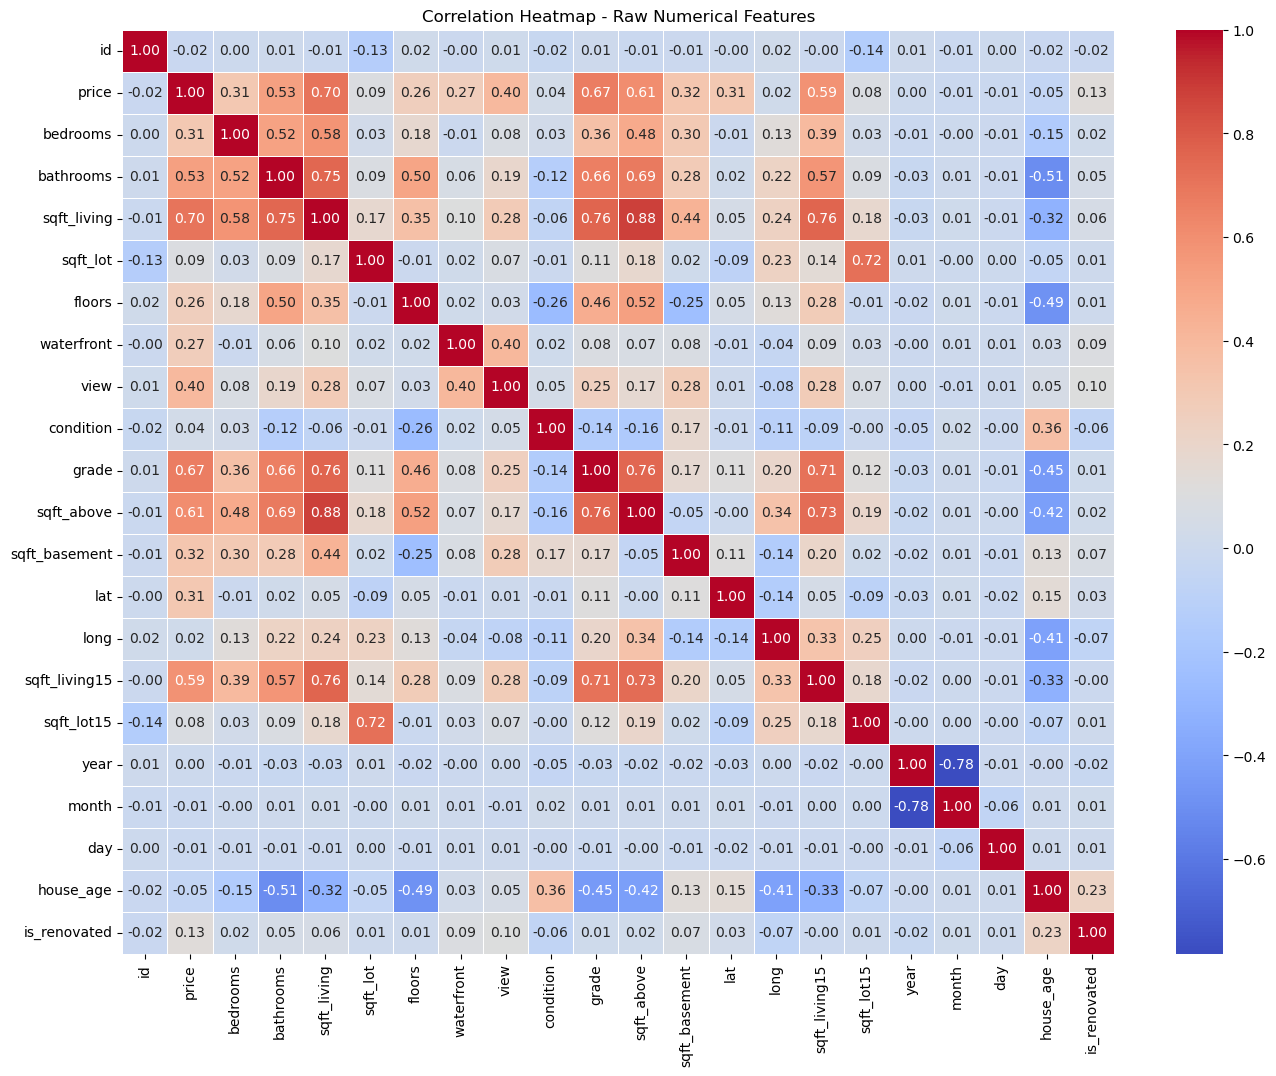

Highly Correlated Features found in raw data:
No features with correlation > 0.9 found.


In [128]:
# Generate the correlation matrix
correlation_matrix = data_final.corr()

# Create the heatmap for visualization
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap - Raw Numerical Features")
plt.show()

# Identify high collinearity pairs (> 0.9)
# We flatten the matrix and filter for values above the threshold
high_corr = correlation_matrix.unstack()
high_corr = high_corr[(abs(high_corr) > 0.9) & (high_corr < 1.0)]

print("Highly Correlated Features found in raw data:")
if not high_corr.empty:
    print(high_corr.sort_values(ascending=False).drop_duplicates())
else:
    print("No features with correlation > 0.9 found.")

We can disregard/drop sqft_above, because it is highly correlated with sqft_living (size of ground zero and size of higher grounds are usually similar). We should also drop "id" as it is not correlated to anything else.
No need for (one-hot-)encoding, because bedrooms/bathrooms/... are ordinal variables that can be interpreted continuously.

In [129]:
data_final = data_final.drop(columns=["id", "sqft_above"])
data_final.to_csv("../data/data_final_kingcounty_houses.csv")
data_final.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_basement,lat,long,sqft_living15,sqft_lot15,year,month,day,house_age,is_renovated
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,0,47.5112,-122.257,1340,5650,2014,10,13,60,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,400,47.7210,-122.319,1690,7639,2014,12,9,64,1
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,0,47.7379,-122.233,2720,8062,2015,2,25,82,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,910,47.5208,-122.393,1360,5000,2014,12,9,50,0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,0,47.6168,-122.045,1800,7503,2015,2,18,28,0


Now we have cleaned the data:
- checked for missing values
- checked for duplicates
- checked for categorical dtypes
- separated numerical columns
- our target: "price"

## Now let us prepare to train a baseline model

First, split the dataset into features (X) and target (y) and rescale all columns

Options:
- max-min Rescaling (to [0,1])
- Z-transform standardizing (use mu and sigma of each column)
We choose z-transform as it is less susceptible to outliers and bounds:

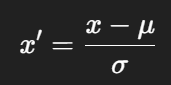

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1: Split BEFORE scaling

X = data_final.drop('price', axis=1)
y = data_final['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Initialize the Scaler (Z-Transform)

scaler = StandardScaler()

# Step 3: Fit and Transform the TRAIN set

X_train_scaled = scaler.fit_transform(X_train)

# Step 4: ONLY Transform the TEST set

X_test_scaled = scaler.transform(X_test)

## Baseline model 1: Linear Regression (-> Lasso/Ridge (Greg))

In [131]:
from sklearn.linear_model import LinearRegression

linreg_model = LinearRegression()
linreg_model.fit(X_train, y_train)
ypred_test_linreg = linreg_model.predict(X_test)
ypred_train_linreg = linreg_model.predict(X_train)


## Baseline model 2: Decision tree

In [138]:
from sklearn.tree import DecisionTreeRegressor

dectree_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dectree_model.fit(X_train, y_train)
ypred_test_dectree = dectree_model.predict(X_test)
ypred_train_dectree = dectree_model.predict(X_train)

## Baseline model 3: XGBoost (no hyperparameter tuning)

In [148]:
import xgboost as xgb

xgb_reg = xgb.XGBRegressor(random_state=42)
xgb_reg.fit(X_train, y_train)
ypred_test_xgb = xgb_reg.predict(X_test)
ypred_train_xgb = xgb_reg.predict(X_train)

## Model Evaluation

Display different metrics like Accuracy, R² and MAE for each model in a common dataframe:

In [149]:
# Dataframe with rows Linear Regression, Decision Tree Regressor and XGBoost
# columns: accuracy_train, accuracy_test, MAE_train, MAE_test, R2_train, R2_test

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_train, ypred_train, y_test, ypred_test):
    return {
        "MAE_train": mean_absolute_error(y_train, ypred_train),
        "MAE_test": mean_absolute_error(y_test, ypred_test),
        
        "RMSE_train": np.sqrt(mean_squared_error(y_train, ypred_train)),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, ypred_test)),
        
        "R²_train": r2_score(y_train, ypred_train),
        "R²_test": r2_score(y_test, ypred_test),
    }

results = pd.DataFrame({
    "Linear Regression": evaluate(y_train, ypred_train_linreg, y_test, ypred_test_linreg),
    "Decision Tree": evaluate(y_train, ypred_train_dectree, y_test, ypred_test_dectree),
    "XGBoost": evaluate(y_train, ypred_train_xgb, y_test, ypred_test_xgb)
}).T

results

,MAE_train,MAE_test,RMSE_train,RMSE_test,R²_train,R²_test
Linear Regression,125097.100489,127579.682149,199057.018473,213945.607203,0.696716,0.697224
Decision Tree,68361.794205,98100.550240,107194.384452,205385.926282,0.912049,0.720966
XGBoost,39090.016975,69145.096824,55437.697466,142748.431148,0.976476,0.865210
